# Crates.io Dependency Network Analysis and Visualizations


## Data Preparation


In [1]:
from enum import Enum
class Snapshot(Enum):
    SNAPSHOT_2018_09_26 = "2018-09-26"
    SNAPSHOT_2020_11_20 = "2020-11-20"
    SNAPSHOT_2022_07_06 = "2022-07-06"
    SNAPSHOT_2024_03_11 = "2024-03-11"
    SNAPSHOT_2026_05_25 = "2026-05-25"


In [ ]:
for snap in Snapshot:
    !git clone --branch snapshot-{snap.value} --depth 1 https://github.com/rust-lang/crates.io-index-archive.git

snapshot_index = r"f:\crates.io-index-archive-snapshot-"
for snap in Snapshot:
    !cargo run -q --release --bin data_preparation -- --index "{snapshot_index}{snap.value}" --output "outputs_{snap.value}" --top-n {100000 + (Snapshot.index(snap) * 20000)}

## Data Analysis

Next, we will load the core edges/nodes, computes metrics, plots degree distributions, and exports small‑world and centrality results.

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from utils import *

### Configuration

In [3]:
from dataclasses import dataclass
date = Snapshot.SNAPSHOT_2018_09_26.value
root_dir = Path(f"outputs_{date}")
@dataclass
class AnalysisConfig:
    edges: Path
    nodes: Path
    out_dir: Path = root_dir / "analysis"
    path_samples: int = 50
    top_k: int = 30
    seed: int = 7
    skip_powerlaw: bool = False
    skip_community: bool = False
    skip_pagerank: bool = False

args = AnalysisConfig(
    edges=root_dir / "core_edges.csv",
    nodes=root_dir / "core_nodes.csv",
    out_dir=root_dir / "analysis",
    top_k=60,
)

### Build and Save Graph

In [4]:
out_dir = args.out_dir
out_dir.mkdir(parents=True, exist_ok=True)

build = True
if build:
    edges = read_edges(args.edges)
    if not edges:
        print("No edges loaded. Check the edges file.")
        sys.exit(1)

    print("Building graph")
    graph = nx.DiGraph()
    graph.add_edges_from(edges)
    if args.nodes:
        graph.add_nodes_from(read_nodes(Path(args.nodes)))

    nx.write_gml(graph, out_dir.parent / "core_graph.gml")
else:
    print("Loading graph from GML")
    graph = nx.read_gml(out_dir.parent / "core_graph.gml")

Building graph


### Basic Network Stats and Connectivity

首先，计算一些基本的网络拓扑指标，建立对这个“地图”的宏观认知。

| 指标 | 计算方式与含义 | 对你的网络意味着什么 |
| :--- | :--- | :--- |
| **节点数、边数、平均度** | `N`, `E`, `<k> = 2E/N` | 了解网络总规模和连接密集程度。 |
| **有向性** | 依赖关系是有向的，区分**入度**（被依赖数）与**出度**（依赖数）。 | 入度分布更能揭示“谁更重要”。 |
| **连通性** | 是否全连通？存在多少个弱连通/强连通分量？ | 分析生态的“孤岛”现象，是否有crate与主流生态完全隔离。 |
| **密度** | `D = E / [N(N-1)]` | 这类真实网络通常非常稀疏，密度极小。 |

> **可视化小技巧**：可以用 `NetworkX` 计算强、弱连通分量，画出最大连通分量的规模占比，这本身就很有说服力。


Basic network stats + connectivity
N=18388, E=53800, avg_in=2.9258, avg_out=2.9258, density=1.591244e-04
reciprocity=3.717472118959108e-05, assortativity(out->in)=-0.03525556955494919
weak components=4259, largest fraction=0.7573
strong components=18387, largest fraction=0.0001


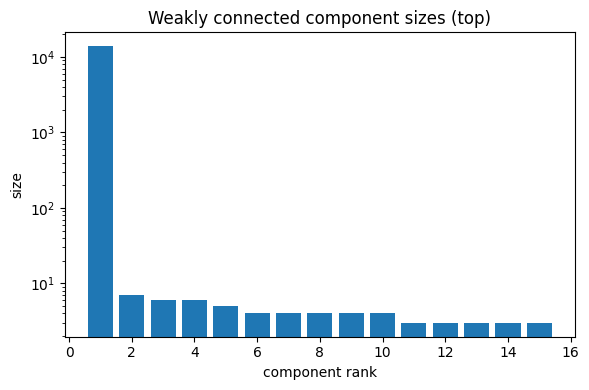

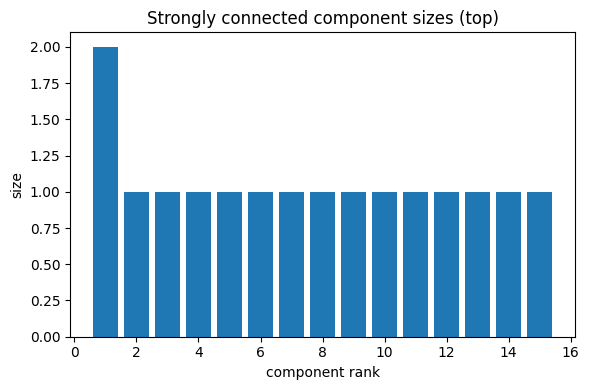

In [5]:
print("Basic network stats + connectivity")
n = graph.number_of_nodes()
m = graph.number_of_edges()
avg_in = (m / n) if n else 0.0
avg_out = (m / n) if n else 0.0
density = nx.density(graph)
reciprocity = nx.reciprocity(graph)
assortativity = None
try:
    assortativity = nx.degree_assortativity_coefficient(graph, x="out", y="in")
except Exception as exc:
    print(f"Assortativity error: {exc}")

weak_sizes = sorted((len(c) for c in nx.weakly_connected_components(graph)), reverse=True)
strong_sizes = sorted((len(c) for c in nx.strongly_connected_components(graph)), reverse=True)
largest_weak = weak_sizes[0] if weak_sizes else 0
largest_strong = strong_sizes[0] if strong_sizes else 0

print(f"N={n}, E={m}, avg_in={avg_in:.4f}, avg_out={avg_out:.4f}, density={density:.6e}")
print(f"reciprocity={reciprocity}, assortativity(out->in)={assortativity}")
print(f"weak components={len(weak_sizes)}, largest fraction={largest_weak / n if n else 0:.4f}")
print(f"strong components={len(strong_sizes)}, largest fraction={largest_strong / n if n else 0:.4f}")

def plot_component_sizes(sizes, title, top=15, log_scale=False):
    if not sizes:
        print(f"{title}: no components")
        return
    top_sizes = sizes[:top]
    plt.figure(figsize=(6, 4))
    plt.bar(range(1, len(top_sizes) + 1), top_sizes)
    if log_scale:
        plt.yscale("log")
    plt.title(title)
    plt.xlabel("component rank")
    plt.ylabel("size")
    plt.tight_layout()
    plt.show()

plot_component_sizes(weak_sizes, "Weakly connected component sizes (top)", log_scale=True)
plot_component_sizes(strong_sizes, "Strongly connected component sizes (top)")

### 验证宏观特性：无标度与小世界

#### 无标度特性（Scale-Free）

*   **分析重点**：只使用**入度分布**（多少其他crate依赖它）。
*   **操作步骤**：
    1.  提取所有节点的入度值，计算概率分布 `P(k)`。
    2.  在双对数坐标下绘制 `P(k) vs k`。
    3.  **用`powerlaw`库进行幂律拟合**，计算最优的 `α` 指数，并执行 KS 检验，得到 `p` 值。
*   **预期发现**：很可能会看到一条大致的直线，但**头部或尾部可能有截断**。这本身就是有趣的讨论点：
    *   尾部截断：意味着“超级巨星”crate的数量比纯幂律分布预测的要少，是不是生态的“压制”效应？
    *   头部偏离：大量只有少数依赖的crate实际分布与幂律拟合线的差异，可以用对数正态分布备择假设进行对比。
*   **进阶对比**：分别对**依赖网络**和**被依赖网络**（即边反向）做分析，看看依赖他人的crate和被人依赖的crate，谁的分布更接近无标度。


Degree stats + plots


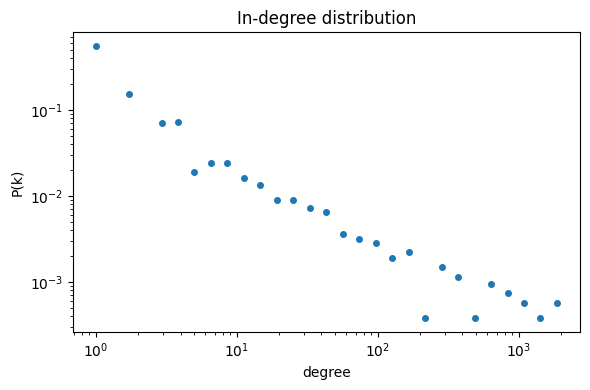

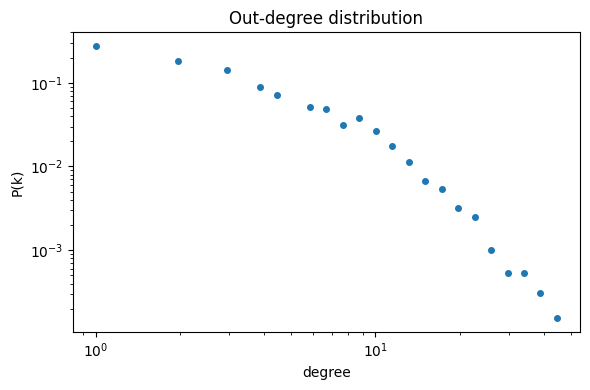

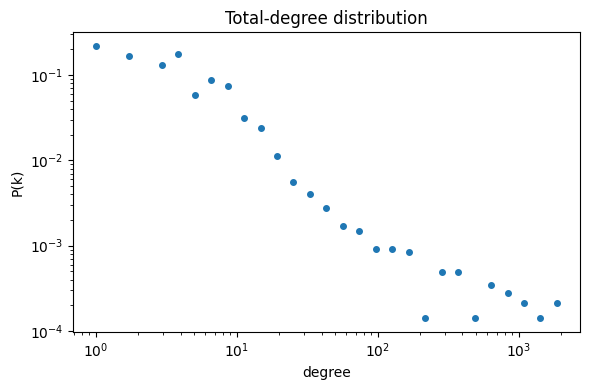

In [6]:
print("Degree stats + plots")
def plot_degree_distribution(degrees: np.ndarray, out_path: Path, title: str) -> None:
    values = degrees[degrees > 0]
    if values.size == 0:
        return
    max_value = values.max()
    if max_value <= 0:
        return

    if max_value <= 1:
        bins = np.array([1, 2])
    else:
        bins = np.logspace(0, math.log10(max_value), num=30)
    hist, bin_edges = np.histogram(values, bins=bins)
    x = bin_edges[:-1]
    y = hist / hist.sum()

    plt.figure(figsize=(6, 4))
    plt.loglog(x, y, marker="o", linestyle="none", markersize=4)
    plt.title(title)
    plt.xlabel("degree")
    plt.ylabel("P(k)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    plt.show()
    plt.close()

in_deg = np.fromiter((deg for _, deg in graph.in_degree()), dtype=int)
out_deg = np.fromiter((deg for _, deg in graph.out_degree()), dtype=int)
total_deg = in_deg + out_deg

metrics = {
    "nodes": graph.number_of_nodes(),
    "edges": graph.number_of_edges(),
    "in_degree": degree_stats(in_deg),
    "out_degree": degree_stats(out_deg),
    "total_degree": degree_stats(total_deg),
}
write_json(out_dir / "metrics.json", metrics)

plot_degree_distribution(in_deg, out_dir / "degree_in.png", "In-degree distribution")
plot_degree_distribution(out_deg, out_dir / "degree_out.png", "Out-degree distribution")
plot_degree_distribution(total_deg, out_dir / "degree_total.png", "Total-degree distribution")



In [7]:
if args.skip_powerlaw:
    print("Powerlaw fit (skipped)")
else:
    print("Powerlaw fit")
    powerlaw_results = {
        "in_degree": fit_powerlaw(in_deg),
        "total_degree": fit_powerlaw(total_deg),
    }
    write_json(out_dir / "powerlaw.json", powerlaw_results)


Powerlaw fit


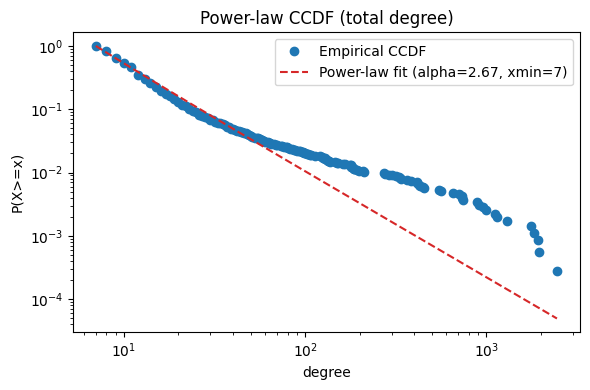

In [8]:
import powerlaw

def plot_powerlaw_ccdf(degrees: np.ndarray, title: str):
    values = degrees[degrees > 0]
    if values.size < 50:
        print("Not enough degree data for powerlaw fit.")
        return None
    fit = powerlaw.Fit(values, discrete=True, verbose=False)

    plt.figure(figsize=(6, 4))
    fit.plot_ccdf(color="tab:blue", marker="o", linestyle="none", label="Empirical CCDF")
    fit.power_law.plot_ccdf(
        color="tab:red",
        linestyle="--",
        label=f"Power-law fit (alpha={fit.alpha:.2f}, xmin={fit.xmin:.0f})",
    )
    plt.title(title)
    plt.xlabel("degree")
    plt.ylabel("P(X>=x)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fit

plot_powerlaw_ccdf(total_deg, "Power-law CCDF (total degree)")

In-degree: alpha=1.855, xmin=1, KS=0.0030, R(pl vs lognormal)=2.943, p=0.2387


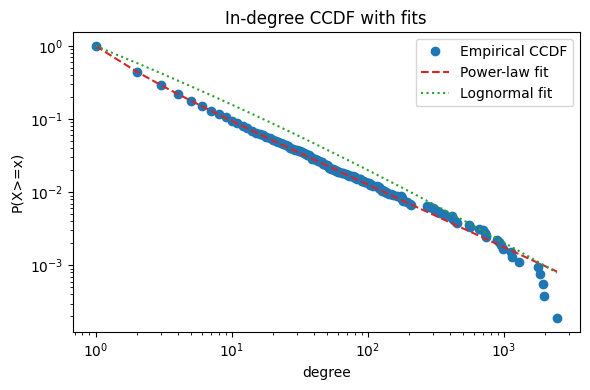

In [9]:
import powerlaw

def powerlaw_compare(degrees: np.ndarray, label: str):
    values = degrees[degrees > 0]
    if values.size < 50:
        print(f"{label}: not enough data")
        return None
    fit = powerlaw.Fit(values, discrete=True, verbose=False)
    R, p = fit.distribution_compare("power_law", "lognormal")
    print(
        f"{label}: alpha={fit.alpha:.3f}, xmin={fit.xmin:.0f}, KS={fit.power_law.D:.4f}, "
        f"R(pl vs lognormal)={R:.3f}, p={p:.4f}"
)

    plt.figure(figsize=(6, 4))
    fit.plot_ccdf(color="tab:blue", marker="o", linestyle="none", label="Empirical CCDF")
    fit.power_law.plot_ccdf(color="tab:red", linestyle="--", label="Power-law fit")
    fit.lognormal.plot_ccdf(color="tab:green", linestyle=":", label="Lognormal fit")
    plt.title(f"{label} CCDF with fits")
    plt.xlabel("degree")
    plt.ylabel("P(X>=x)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return fit

powerlaw_compare(in_deg, "In-degree")

#### 小世界特性（Small-World）

*   **计算指标**：
    *   **聚类系数 C**：需要先将有向图转为无向图（或使用有向聚类系数），计算平均聚类系数。
    *   **平均最短路径长度 L**：同样在无向化后计算（确保连通），或取最大弱连通分量来计算。
*   **统计检验**：
    *   生成 100 个具有相同节点数和边数的 **ER随机图**（或配置模型，以保持度序列）。
    *   计算这些小世界系数的**均值和置信区间**。
    *   如果你的 `σ` 显著大于 1（比如 `> 10`），就可以自信地宣布它具备小世界特性。
*   **意义解读**：小世界意味着**依赖传递极快**。一个底层的 `serde` 升级，影响力可以在几步内波及几乎整个生态，这对理解供应链风险至关重要。


In [10]:
print("Small-world comparison")
rng = random.Random(args.seed)
undirected = graph.to_undirected()
undirected = largest_component_graph(undirected)

Small-world comparison


In [11]:
real_clustering = (
    nx.average_clustering(undirected) if undirected.number_of_nodes() > 0 else 0.0
)
real_path = estimate_average_shortest_path_length(undirected, args.path_samples, rng)

random_graph = nx.gnm_random_graph(
    undirected.number_of_nodes(), undirected.number_of_edges(), seed=args.seed
)
random_graph = largest_component_graph(random_graph)
random_clustering = (
    nx.average_clustering(random_graph) if random_graph.number_of_nodes() > 0 else 0.0
)
random_path = estimate_average_shortest_path_length(random_graph, args.path_samples, rng)

gamma = None
if random_clustering:
    gamma = real_clustering / random_clustering
lambda_value = None
if random_path:
    lambda_value = real_path / random_path
sigma = None
if gamma is not None and lambda_value:
    sigma = gamma / lambda_value

small_world = {
    "real": {
        "nodes": undirected.number_of_nodes(),
        "edges": undirected.number_of_edges(),
        "clustering": real_clustering,
        "avg_path_length": real_path,
    },
    "random": {
        "nodes": random_graph.number_of_nodes(),
        "edges": random_graph.number_of_edges(),
        "clustering": random_clustering,
        "avg_path_length": random_path,
    },
    "gamma": gamma,
    "lambda": lambda_value,
    "sigma": sigma,
}
write_json(out_dir / "small_world.json", small_world)


### 供应链风险模拟：鲁棒性分析

这是最能体现“复杂网络分析价值”的部分，可以量化回答：“**Crates.io 的供应链有多脆弱？**”

*   **1. 随机故障与蓄意攻击**
    *   **模拟**：逐步移除节点，并计算网络**最大连通分量**的大小变化。
    *   **对比两种策略**：
        *   **随机移除**：模拟自然的crate弃坑或偶然故障。
        *   **蓄意攻击**：按入度、介数中心性等从高到低依次移除。
    *   **结果预测**：你的网络很可能会表现出**对随机故障极其鲁棒，但对蓄意攻击高度脆弱**的经典无标度特征。
*   **2. 级联失效仿真**
    *   不只是一次移除一个，而是设定一个规则：当一个节点的“负载”超过阈值就“失效”，并将其负载传递给邻居。
    *   这可以模拟“某一版本被yanked”引发的连锁反应。
*   **3. “最大依存链”与版本脆弱性**
    *   统计从每个crate到生态根部的最大依赖链长度。极度长的链条意味着任何一环断裂都会导致整个链上的项目构建失败。
    *   可识别出那些生态中依赖链最深、最缺乏“隔离保护”的crate。


Robustness simulation (random vs targeted removal)


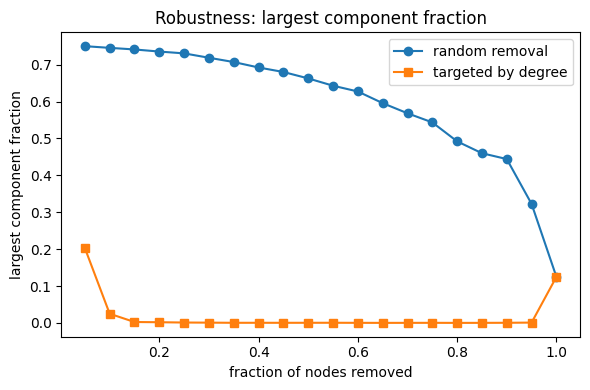

[(np.float64(0.05), 0.7501, 0.2031), (np.float64(0.1), 0.7456, 0.025), (np.float64(0.15), 0.7412, 0.0026), (np.float64(0.2), 0.7355, 0.002), (np.float64(0.25), 0.7306, 0.0012), (np.float64(0.3), 0.7187, 0.0009), (np.float64(0.35), 0.7071, 0.0005), (np.float64(0.4), 0.6924, 0.0005), (np.float64(0.45), 0.6801, 0.0005), (np.float64(0.5), 0.6628, 0.0005), (np.float64(0.55), 0.643, 0.0006), (np.float64(0.6), 0.6273, 0.0004), (np.float64(0.65), 0.5957, 0.0003), (np.float64(0.7), 0.5683, 0.0004), (np.float64(0.75), 0.5436, 0.0004), (np.float64(0.8), 0.4921, 0.0003), (np.float64(0.85), 0.46, 0.0004), (np.float64(0.9), 0.4442, 0.0005), (np.float64(0.95), 0.3225, 0.0011), (np.float64(1.0), 0.125, 0.125)]


In [5]:
def largest_cc_fraction(g: nx.Graph) -> float:
    if g.number_of_nodes() == 0:
        return 0.0
    return max(len(c) for c in nx.connected_components(g)) / g.number_of_nodes()

def robustness_curve(g: nx.Graph, steps: int, strategy: str, seed: int):
    rng = random.Random(seed)
    nodes = list(g.nodes())
    if strategy == "targeted":
        nodes = [n for n, _ in sorted(g.degree(), key=lambda x: x[1], reverse=True)]
    else:
        rng.shuffle(nodes)
    chunk = max(1, len(nodes) // steps)
    g = g.copy()
    fractions = []
    for i in range(steps):
        for node in nodes[i * chunk:(i + 1) * chunk]:
            if g.has_node(node):
                g.remove_node(node)
        fractions.append(largest_cc_fraction(g))
    return fractions

print("Robustness simulation (random vs targeted removal)")
if "undirected" not in globals():
    undirected = graph.to_undirected()

g_rob = undirected
# max_nodes = 40000
# if g_rob.number_of_nodes() > max_nodes:
#     rng = random.Random(args.seed if "args" in globals() else 7)
#     sample_nodes = rng.sample(list(g_rob.nodes()), max_nodes)
#     g_rob = g_rob.subgraph(sample_nodes).copy()
#     print(f"Using sampled graph for robustness: {g_rob.number_of_nodes()} nodes")

steps = 20
random_curve = robustness_curve(g_rob, steps=steps, strategy="random", seed=7)
targeted_curve = robustness_curve(g_rob, steps=steps, strategy="targeted", seed=7)

x = np.linspace(1 / steps, 1, steps)
plt.figure(figsize=(6, 4))
plt.plot(x, random_curve, marker="o", label="random removal")
plt.plot(x, targeted_curve, marker="s", label="targeted by degree")
plt.title("Robustness: largest component fraction")
plt.xlabel("fraction of nodes removed")
plt.ylabel("largest component fraction")
plt.legend()
plt.tight_layout()
plt.show()
print(list(map(lambda x: (round(x[0], 4), round(x[1], 4), round(x[2], 4)),zip(x, random_curve, targeted_curve))))

In [13]:
if args.skip_pagerank:
    print("PageRank export (skipped)")
else:
    print("PageRank export")
    export_top_centrality(out_dir / "centrality.csv", graph, args.top_k)
print(f"Nodes: {graph.number_of_nodes()}")
print(f"Edges: {graph.number_of_edges()}")
print(f"Outputs: {out_dir}")


PageRank export
Nodes: 18388
Edges: 53800
Outputs: outputs_2018-09-26\analysis



Expected inputs:
- outputs/core_edges.csv
- outputs/core_nodes.csv (optional)
- outputs/analysis/metrics.json
- outputs/analysis/powerlaw.json
- outputs/analysis/small_world.json
- outputs/analysis/centrality.csv

In [19]:
analysis_dir = root_dir / "analysis"
edges_path = root_dir / "core_edges.csv"
nodes_path = root_dir / "core_nodes.csv"
metrics_path = analysis_dir / "metrics.json"
powerlaw_path = analysis_dir / "powerlaw.json"
small_world_path = analysis_dir / "small_world.json"
centrality_path = analysis_dir / "centrality.csv"

In [20]:
def load_json(path: Path):
    if not path.exists():
        print(f"Missing: {path}")
        return None
    with path.open(encoding="utf-8") as handle:
        return json.load(handle)

metrics = load_json(metrics_path)
powerlaw_info = load_json(powerlaw_path)
small_world = load_json(small_world_path)

print("metrics.json", metrics is not None)
print("powerlaw.json", powerlaw_info is not None)
print("small_world.json", small_world is not None)

if small_world:
    print("Small-world summary:")
    print(json.dumps({
        "gamma": small_world.get("gamma"),
        "lambda": small_world.get("lambda"),
        "sigma": small_world.get("sigma"),
        "real": small_world.get("real"),
    }, indent=2))

metrics.json True
powerlaw.json True
small_world.json True
Small-world summary:
{
  "gamma": 354.36407008212177,
  "lambda": 0.7913499511783036,
  "sigma": 447.7969191183762,
  "real": {
    "nodes": 13925,
    "edges": 53580,
    "clustering": 0.19289009584829242,
    "avg_path_length": 3.8159322033898304
  }
}


In [21]:
def load_centrality(path: Path, top_k: int = 20):
    if not path.exists():
        print(f"Missing: {path}")
        return []
    rows = []
    with path.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            try:
                rank = int(row.get("rank", 0))
            except ValueError:
                continue
            name = row.get("name")
            score = float(row.get("pagerank", 0.0))
            rows.append((rank, name, score))
    rows = sorted(rows, key=lambda item: item[0])[:top_k]
    return rows

top_nodes = load_centrality(centrality_path, top_k=60)
if top_nodes:
    for rank, name, score in top_nodes[:10]:
        print(rank, name, score)

1 libc 0.035969
2 winapi 0.018851
3 cfg-if 0.016365
4 serde 0.015211
5 unicode-xid 0.014244
6 num-traits 0.013155
7 proc-macro2 0.013093
8 log 0.011389
9 byteorder 0.011313
10 rand 0.010356


### 识别关键节点：用中心性寻找“基础设施”

在验证了宏观特征后，可以深入挖掘哪些节点是网络的真正“支柱”。推荐以下几种互补的中心性指标：

1.  **入度中心性**：最直观的“流行度”指标。找到 `serde`, `rand`, `tokio` 等预料之内的明星。
2.  **介数中心性**：衡量一个节点在多少对最短路径上扮演“桥梁”角色。**它往往能发现意想不到的关键crate**，比如一些工具库（`proc-macro2`, `quote`, `syn`），它们虽然不一定是被依赖最多的，但处于信息流（依赖路径）的要冲，一旦失效会导致大量依赖链断裂。
3.  **PageRank**：考虑邻居的“质量”的影响力，很适合在有向网络中使用。可以让你的排名结论更有说服力。
4.  **结构洞与桥接节点**：寻找那些连接着不同社区/板块（比如连接`嵌入式`社区和`Web`社区的crate）的关键节点。它们的脆弱性可能引发生态的“社区割裂”。

**实践建议**：列出一个**Top 20 综合影响力榜单**，对比不同中心性指标下的排名差异，分析为什么某个crate在介数中心性上排名异常高，这本身就是很好的课程报告素材。


In [22]:
print("Centrality comparison (in-degree, PageRank, betweenness)")
top_in_degree = sorted(graph.in_degree(), key=lambda x: x[1], reverse=True)[:20]
print("Top 20 by in-degree:")
for rank, (name, score) in enumerate(top_in_degree, start=1):
    print(rank, name, score)

pagerank_map = {name: score for _, name, score in top_nodes} if top_nodes else {}
if pagerank_map:
    print("Top PageRank (from centrality.csv):")
    for rank, name, score in top_nodes[:20]:
        print(rank, name, score)

betweenness_subgraph_size = 2000
betweenness_sample_k = 200
deg_sorted = sorted(graph.in_degree(), key=lambda x: x[1], reverse=True)
betw_nodes = [name for name, _ in deg_sorted[:betweenness_subgraph_size]]
betw_sub = graph.subgraph(betw_nodes).to_undirected()

if betw_sub.number_of_nodes() > 1:
    if betw_sub.number_of_nodes() > betweenness_sample_k:
        betw = nx.betweenness_centrality(betw_sub, k=betweenness_sample_k, seed=7)
        print(f"Betweenness computed with k={betweenness_sample_k} on {betw_sub.number_of_nodes()} nodes")
    else:
        betw = nx.betweenness_centrality(betw_sub)
    top_betw = sorted(betw.items(), key=lambda x: x[1], reverse=True)[:20]
    print("Top 20 by betweenness (subgraph):")
    for rank, (name, score) in enumerate(top_betw, start=1):
        print(rank, name, f"{score:.6f}")
else:
    print("Betweenness subgraph too small.")

Centrality comparison (in-degree, PageRank, betweenness)
Top 20 by in-degree:
1 serde 2451
2 serde_derive 1956
3 libc 1927
4 serde_json 1834
5 log 1771
6 clap 1298
7 rand 1149
8 lazy_static 1121
9 hyper 978
10 regex 952
11 byteorder 914
12 futures 883
13 failure 741
14 chrono 736
15 winapi 730
16 url 699
17 error-chain 653
18 time 561
19 rustc-serialize 550
20 bitflags 450
Top PageRank (from centrality.csv):
1 libc 0.035969
2 winapi 0.018851
3 cfg-if 0.016365
4 serde 0.015211
5 unicode-xid 0.014244
6 num-traits 0.013155
7 proc-macro2 0.013093
8 log 0.011389
9 byteorder 0.011313
10 rand 0.010356
11 lazy_static 0.009338
12 rand_core 0.009092
13 winapi-i686-pc-windows-gnu 0.008089
14 winapi-x86_64-pc-windows-gnu 0.008089
15 serde_derive 0.00727
16 serde_json 0.007218
17 syn 0.007105
18 quote 0.00699
19 bitflags 0.00695
20 clap 0.006666
Betweenness computed with k=200 on 2000 nodes
Top 20 by betweenness (subgraph):
1 libc 0.218701
2 log 0.113385
3 serde 0.083572
4 byteorder 0.070566
5 lazy

In [23]:
def compute_degrees_and_subgraph_edges(edges_file: Path, top_names: set[str]):
    in_degree: dict[str, int] = {}
    out_degree: dict[str, int] = {}
    sub_edges: list[tuple[str, str]] = []

    with edges_file.open(newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        for row in tqdm(reader, desc="Scanning edges", unit="edges"):
            src = row.get("src")
            dst = row.get("dst")
            if not src or not dst:
                continue
            out_degree[src] = out_degree.get(src, 0) + 1
            in_degree[dst] = in_degree.get(dst, 0) + 1
            if src in top_names and dst in top_names:
                sub_edges.append((src, dst))

    all_nodes = set(in_degree) | set(out_degree)
    in_deg = np.array([in_degree.get(n, 0) for n in all_nodes])
    out_deg = np.array([out_degree.get(n, 0) for n in all_nodes])
    total_deg = in_deg + out_deg
    return in_deg, out_deg, total_deg, sub_edges

if not edges_path.exists():
    raise FileNotFoundError(edges_path)

top_names = {name for _, name, _ in top_nodes} if top_nodes else set()
in_deg, out_deg, total_deg, sub_edges = compute_degrees_and_subgraph_edges(edges_path, top_names)
print("Degree arrays", in_deg.size, out_deg.size, total_deg.size)
print("Subgraph edges", len(sub_edges))

Scanning edges: 53800edges [00:00, 811041.18edges/s]

Degree arrays 14287 14287 14287
Subgraph edges 70


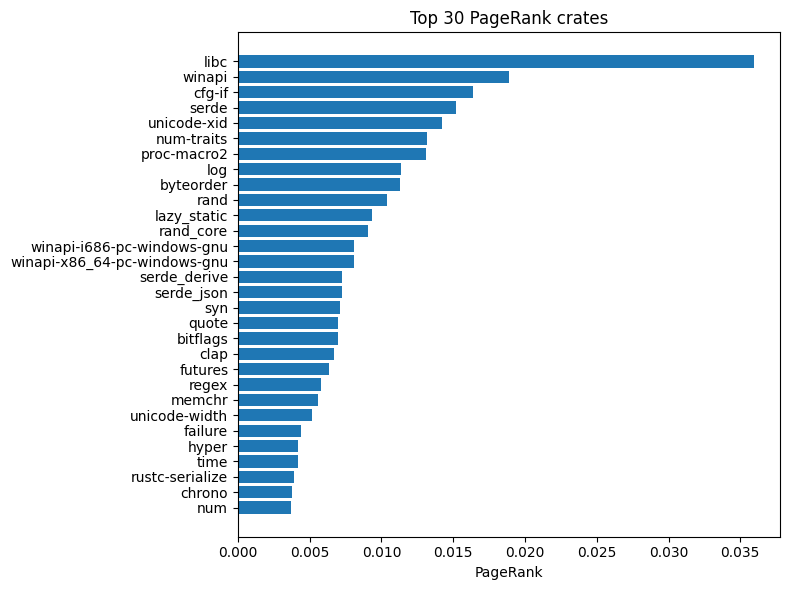

In [25]:
if top_nodes:
    ranks = [rank for rank, _, _ in top_nodes[:30]]
    names = [name for _, name, _ in top_nodes[:30]]
    scores = [score for _, _, score in top_nodes[:30]]

    plt.figure(figsize=(8, 6))
    plt.barh(names[::-1], scores[::-1])
    plt.title("Top 30 PageRank crates")
    plt.xlabel("PageRank")
    plt.tight_layout()
    plt.show()
else:
    print("centrality.csv not found or empty")

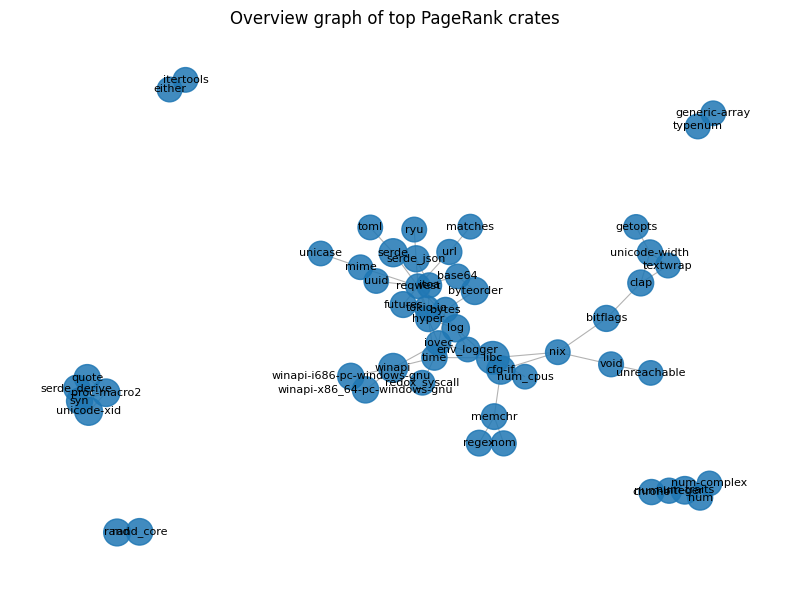

In [26]:
if sub_edges and top_nodes:
    subgraph = nx.DiGraph()
    subgraph.add_edges_from(sub_edges)

    size_map = {name: score for _, name, score in top_nodes}
    sizes = [300 + 7000 * size_map.get(node, 0.0) for node in subgraph.nodes()]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(subgraph.to_undirected(), seed=7)
    nx.draw_networkx_nodes(subgraph, pos, node_size=sizes, node_color="#1f77b4", alpha=0.85)
    nx.draw_networkx_edges(subgraph, pos, arrows=False, width=0.8, alpha=0.3)
    nx.draw_networkx_labels(subgraph, pos, font_size=8)
    plt.title("Overview graph of top PageRank crates")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No subgraph edges available.")